In [ ]:

## Description

# This Jupyter File was created to generate a path that would avoid the obstacles defined within the workspace ...
# ...using A star Algoritham
# ...This file also is used to control the UR5e Robot via RTDE control interface. 


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def is_collision_free(start, end, obstacles):
    """
    Checks if the line segment from start to end is free from collision with obstacles.
    start: Start point as a list or numpy array [x, y, z].
    end: End point as a list or numpy array [x, y, z].
    obstacles: List of obstacles, where each obstacle is a tuple (center, radius).
                      center: [x, y, z] coordinates of the obstacle center.
                      radius: Radius of the spherical obstacle.
    :return: True if the path is collision-free, False otherwise.
    """
    start = np.array(start)
    end = np.array(end)

    for obstacle_center, obstacle_radius in obstacles:
        obstacle_center = np.array(obstacle_center)

        # Vector from start to end
        segment_vector = end - start

        # Vector from start to obstacle center
        center_vector = obstacle_center - start

        # Project the center_vector onto the segment_vector
        segment_length = np.linalg.norm(segment_vector)
        if segment_length == 0:
            continue  # Avoid division by zero for coincident points
        unit_segment = segment_vector / segment_length
        projection_length = np.dot(center_vector, unit_segment)

        # Closest point on the line segment to the obstacle center
        if projection_length < 0:
            closest_point = start
        elif projection_length > segment_length:
            closest_point = end
        else:
            closest_point = start + projection_length * unit_segment

        # Distance from the obstacle center to the closest point
        distance_to_center = np.linalg.norm(obstacle_center - closest_point)

        # Check if this distance is less than the obstacle radius
        if distance_to_center <= obstacle_radius:
            return False  # Collision detected

    return True  # No collision

def a_star(start, goal, workspace_bounds, obstacles, resolution=0.05):

    bounds_min = np.array([b[0] for b in workspace_bounds])
    bounds_max = np.array([b[1] for b in workspace_bounds])

    def index_to_point(index):
        return bounds_min + np.array(index) * resolution


    def point_to_index(point):
        return np.round((np.array(point) - bounds_min) / resolution).astype(int)

    def h_cost(p1, p2):
        return np.linalg.norm(np.array(p1) - np.array(p2))
    """
    def h_cost(p1, p2):
    return np.abs(p1[0] - p2[0]) + np.abs(p1[1] - p2[1]) + np.abs(p1[2] - p2[2])
    # using manhattan distance will make the movement through axis, it can be used when the we dont want diagonal movement
    """

    start_index = tuple(point_to_index(start))
    goal_index = tuple(point_to_index(goal))

    open_set = {start_index: 0}
    came_from = {}
    g_score = {start_index: 0}
    f_score = {start_index: h_cost(start, goal)}

    visited = set()

    #possible directions*26
    directions = [
        np.array([dx, dy, dz])
        for dx in [-1, 0, 1]
        for dy in [-1, 0, 1]
        for dz in [-1, 0, 1]
        if not (dx == 0 and dy == 0 and dz == 0)
    ]

    while open_set:
        current_index = min(open_set, key=lambda k: f_score.get(k, float('inf')))
        current_point = index_to_point(current_index)

        if current_index == goal_index:
            path = []
            while current_index in came_from:
                path.append(index_to_point(current_index))
                current_index = came_from[current_index]
            path.append(start)
            return path[::-1]

        open_set.pop(current_index)
        visited.add(current_index)

        for direction in directions:
            neighbor_index = tuple(np.array(current_index) + direction)
            neighbor_point = index_to_point(neighbor_index)

            if not np.all(bounds_min <= neighbor_point) or not np.all(neighbor_point <= bounds_max):
                continue  # Out of bounds

            if neighbor_index in visited:
                continue

            if not is_collision_free(current_point, neighbor_point, obstacles):
                continue

            tentative_g_score = g_score[current_index] + h_cost(current_point, neighbor_point)

            if neighbor_index not in g_score or tentative_g_score < g_score[neighbor_index]:
                came_from[neighbor_index] = current_index
                g_score[neighbor_index] = tentative_g_score
                f_score[neighbor_index] = tentative_g_score + h_cost(neighbor_point, goal)
                open_set[neighbor_index] = f_score[neighbor_index]

    return []  # No path found

In [2]:
#trial remove as pleased
if __name__ == "__main__":
    workspace_bounds = [[0, 1], [0, 1], [0, 1]]
    obstacles = [
        (np.array([0.25, 0.25, 0.25]), 0.05),
        (np.array([0.5, 0.5, 0.4]), 0.10),
        (np.array([0.65, 0.65, 0.65]), 0.15)
    ]
    start = [0.1, 0.1, 0.1]
    goal = [0.9, 0.9, 0.9]

    path = a_star(start, goal, workspace_bounds, obstacles, resolution=0.05)

    if path:
        print("Path found:")
        for point in path:
            print(point)
    else:
        print("No path found.")

Path found:
[0.1, 0.1, 0.1]
[0.15 0.15 0.15]
[0.2 0.2 0.2]
[0.2  0.2  0.25]
[0.2 0.2 0.3]
[0.25 0.25 0.35]
[0.3 0.3 0.4]
[0.35 0.35 0.45]
[0.4 0.4 0.5]
[0.45 0.45 0.55]
[0.5 0.5 0.6]
[0.5  0.5  0.65]
[0.5 0.5 0.7]
[0.55 0.55 0.75]
[0.6 0.6 0.8]
[0.65 0.65 0.8 ]
[0.7  0.7  0.85]
[0.75 0.75 0.85]
[0.8  0.8  0.85]
[0.85 0.85 0.9 ]
[0.9 0.9 0.9]


In [3]:
# Function to plot the spherical obstacles
def plot_obstacles(ax, obstacles):
    for center, radius in obstacles:
        u = np.linspace(0, 2 * np.pi, 100)
        v = np.linspace(0, np.pi, 100)
        # Create a sphere using parametric equations
        x = center[0] + radius * np.outer(np.cos(u), np.sin(v))
        y = center[1] + radius * np.outer(np.sin(u), np.sin(v))
        z = center[2] + radius * np.outer(np.ones(np.size(u)), np.cos(v))
        ax.plot_surface(x, y, z, color='r', alpha=0.3)  # Red transparent spheres

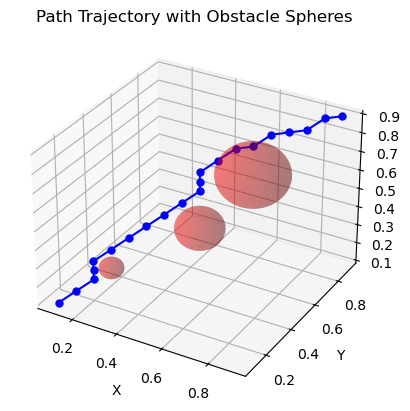

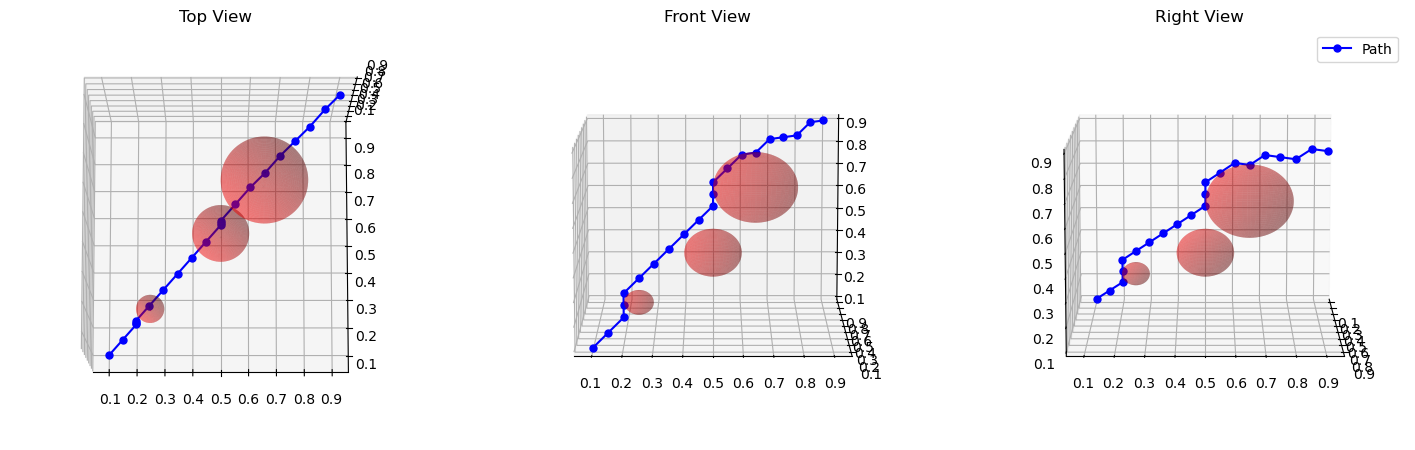

In [4]:
# Create the 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the obstacles
plot_obstacles(ax, obstacles)

# Plot the path trajectory (line through the points)
if path:
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], path[:, 2], marker='.', color='b', label='Path', markersize=10)

# Customize the plot
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Path Trajectory with Obstacle Spheres')

# Display the plot with multiple views
fig = plt.figure(figsize=(18, 6))

# Top view
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_title("Top View")
if len(path) > 0:  # Check if the path is not empty
    ax1.plot(np.array(path)[:, 0], np.array(path)[:, 1], np.array(path)[:, 2], label="Path", color='b', marker='.', markersize=10)
    ax1.view_init(elev=80, azim=-90)
plot_obstacles(ax1, obstacles)

# Front view
ax2 = fig.add_subplot(132, projection='3d')
ax2.set_title("Front View")
if len(path) > 0:
    ax2.plot(path[:, 0], path[:, 1], path[:, 2], label="Path", color='b', marker='.', markersize=10)
ax2.view_init(elev=10, azim=-90)
plot_obstacles(ax2, obstacles)

# Right view
ax3 = fig.add_subplot(133, projection='3d')
ax3.set_title("Right View")
if len(path) > 0:
    ax3.plot(path[:, 0], path[:, 1], path[:, 2], label="Path", color='b', marker='.', markersize=10)
ax3.view_init(elev=10, azim=0)
plot_obstacles(ax3, obstacles)

# Display the plot
plt.legend()
plt.show()

In [ ]:
def smooth_path(path, obstacles):
    """
    Smooths the path by removing unnecessary intermediate points.

    """
    if not path:
        return []

    smoothed_path = [path[0]]  # Start with the first point
    current_point = path[0]

    for i in range(1, len(path)):
        if not is_collision_free(current_point, path[i], obstacles):
            # If collision detected, add the previous point to the path
            smoothed_path.append(path[i - 1])
            current_point = path[i - 1]

    # Add the last point
    smoothed_path.append(path[-1])
    return smoothed_path


In [ ]:
def optimize_path(path, obstacles, iterations=10, alpha=0.1):
    """
    Optimizes the path by reducing sharp turns while avoiding obstacles.

    """
    path = np.array(path)  # Convert path to numpy array
    optimized_path = path.copy()

    for _ in range(iterations):
        for i in range(1, len(path) - 1):  # Skip start and end points
            prev_point = optimized_path[i - 1]
            next_point = optimized_path[i + 1]

            # Move point towards the midpoint of its neighbors
            midpoint = (prev_point + next_point) / 2
            if is_collision_free(prev_point, midpoint, obstacles) and \
               is_collision_free(midpoint, next_point, obstacles):
                optimized_path[i] = (1 - alpha) * optimized_path[i] + alpha * midpoint

    return optimized_path


In [13]:
raw_path = a_star(start, goal, workspace_bounds, obstacles, resolution=0.05)

In [15]:
print(raw_path)

[[0.1, 0.1, 0.1], array([0.15, 0.15, 0.15]), array([0.2, 0.2, 0.2]), array([0.2 , 0.2 , 0.25]), array([0.2, 0.2, 0.3]), array([0.25, 0.25, 0.35]), array([0.3, 0.3, 0.4]), array([0.35, 0.35, 0.45]), array([0.4, 0.4, 0.5]), array([0.45, 0.45, 0.55]), array([0.5, 0.5, 0.6]), array([0.5 , 0.5 , 0.65]), array([0.5, 0.5, 0.7]), array([0.55, 0.55, 0.75]), array([0.6, 0.6, 0.8]), array([0.65, 0.65, 0.8 ]), array([0.7 , 0.7 , 0.85]), array([0.75, 0.75, 0.85]), array([0.8 , 0.8 , 0.85]), array([0.85, 0.85, 0.9 ]), array([0.9, 0.9, 0.9])]


In [17]:
smoothed_path = smooth_path(raw_path, obstacles)
print(smoothed_path)

[[0.1, 0.1, 0.1], array([0.3, 0.3, 0.4]), array([0.6, 0.6, 0.8]), array([0.9, 0.9, 0.9])]


In [19]:
smoothed_path1 = optimize_path(raw_path, obstacles)
print(smoothed_path1)

[[0.1        0.1        0.1       ]
 [0.14662418 0.14662418 0.15      ]
 [0.18301923 0.18301923 0.2       ]
 [0.19944685 0.19944685 0.25      ]
 [0.21670961 0.21670961 0.3       ]
 [0.25391794 0.25391794 0.35      ]
 [0.30071662 0.30071662 0.4       ]
 [0.35006977 0.35006977 0.45      ]
 [0.39956139 0.39956139 0.5       ]
 [0.44656616 0.44656616 0.55      ]
 [0.48301243 0.48301243 0.6       ]
 [0.4994457  0.4994457  0.65      ]
 [0.51670262 0.51670262 0.7       ]
 [0.55383546 0.55383546 0.75      ]
 [0.6        0.6        0.8       ]
 [0.65       0.65       0.81347811]
 [0.7        0.7        0.83692521]
 [0.75       0.75       0.84971852]
 [0.8        0.8        0.86339739]
 [0.85       0.85       0.88699386]
 [0.9        0.9        0.9       ]]


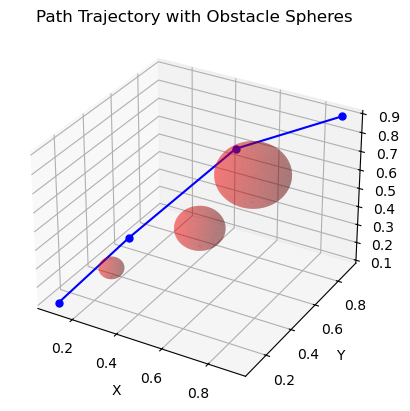

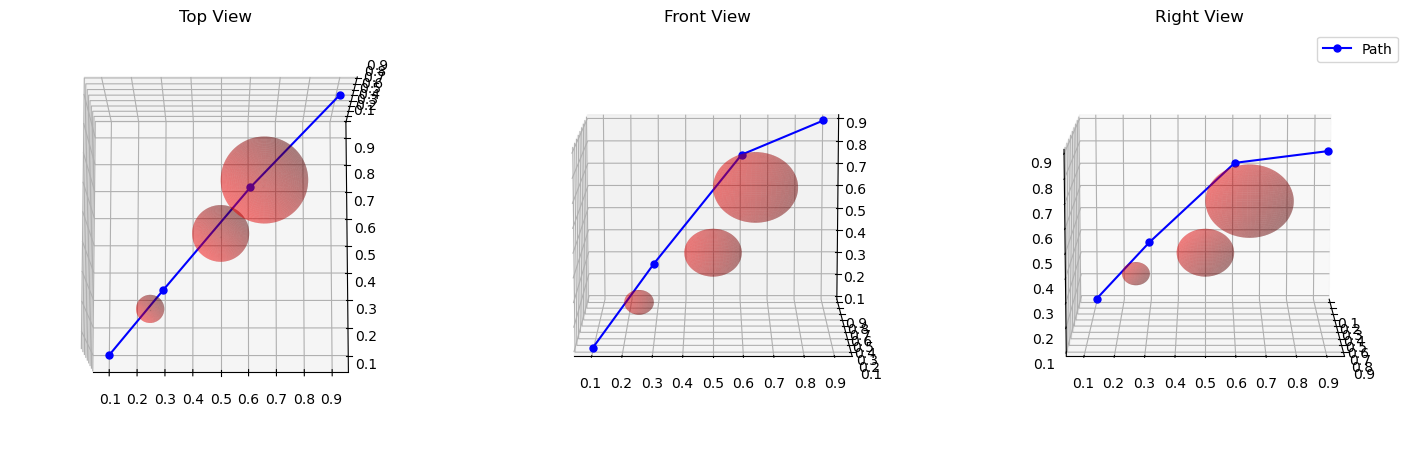

In [27]:
# Create the 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the obstacles
plot_obstacles(ax, obstacles)

# Plot the path trajectory (line through the points)
if smoothed_path is not None and smoothed_path.size > 0:  # Check if the array is not empty
    smoothed_path = np.array(smoothed_path)
    ax.plot(smoothed_path[:, 0], smoothed_path[:, 1], smoothed_path[:, 2], 
            marker='.', color='b', label='Path', markersize=10)

# Customize the plot
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Path Trajectory with Obstacle Spheres')

# Display the plot with multiple views
fig = plt.figure(figsize=(18, 6))

# Top view
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_title("Top View")
if len(smoothed_path) > 0:  # Check if the path is not empty
    ax1.plot(np.array(smoothed_path)[:, 0], np.array(smoothed_path)[:, 1], np.array(smoothed_path)[:, 2], label="Path", color='b', marker='.', markersize=10)
    ax1.view_init(elev=80, azim=-90)
plot_obstacles(ax1, obstacles)

# Front view
ax2 = fig.add_subplot(132, projection='3d')
ax2.set_title("Front View")
if len(smoothed_path) > 0:
    ax2.plot(smoothed_path[:, 0], smoothed_path[:, 1], smoothed_path[:, 2], label="Path", color='b', marker='.', markersize=10)
ax2.view_init(elev=10, azim=-90)
plot_obstacles(ax2, obstacles)

# Right view
ax3 = fig.add_subplot(133, projection='3d')
ax3.set_title("Right View")
if len(smoothed_path) > 0:
    ax3.plot(smoothed_path[:, 0], smoothed_path[:, 1], smoothed_path[:, 2], label="Path", color='b', marker='.', markersize=10)
ax3.view_init(elev=10, azim=0)
plot_obstacles(ax3, obstacles)

# Display the plot
plt.legend()
plt.show()

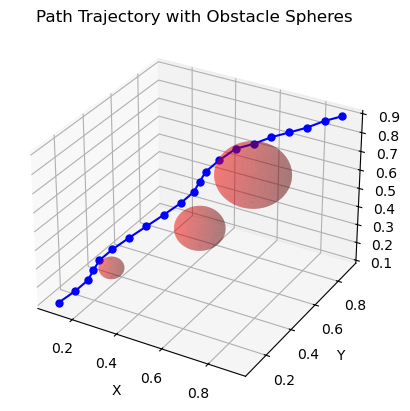

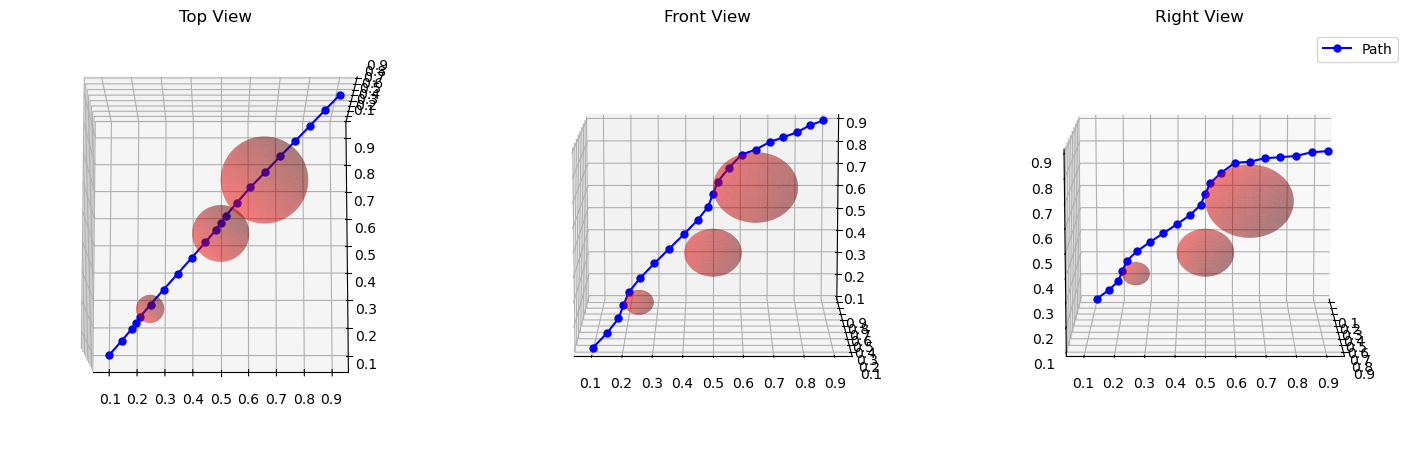

In [29]:
# Create the 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the obstacles
plot_obstacles(ax, obstacles)

# Plot the path trajectory (line through the points)
if smoothed_path1 is not None and smoothed_path1.size > 0:  # Check if the array is not empty
    smoothed_path1 = np.array(smoothed_path1)
    ax.plot(smoothed_path1[:, 0], smoothed_path1[:, 1], smoothed_path1[:, 2], 
            marker='.', color='b', label='Path', markersize=10)

# Customize the plot
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Path Trajectory with Obstacle Spheres')

# Display the plot with multiple views
fig = plt.figure(figsize=(18, 6))

# Top view
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_title("Top View")
if len(smoothed_path1) > 0:  # Check if the path is not empty
    ax1.plot(np.array(smoothed_path1)[:, 0], np.array(smoothed_path1)[:, 1], np.array(smoothed_path1)[:, 2], label="Path", color='b', marker='.', markersize=10)
    ax1.view_init(elev=80, azim=-90)
plot_obstacles(ax1, obstacles)

# Front view
ax2 = fig.add_subplot(132, projection='3d')
ax2.set_title("Front View")
if len(smoothed_path1) > 0:
    ax2.plot(smoothed_path1[:, 0], smoothed_path1[:, 1], smoothed_path1[:, 2], label="Path", color='b', marker='.', markersize=10)
ax2.view_init(elev=10, azim=-90)
plot_obstacles(ax2, obstacles)

# Right view
ax3 = fig.add_subplot(133, projection='3d')
ax3.set_title("Right View")
if len(smoothed_path1) > 0:
    ax3.plot(smoothed_path1[:, 0], smoothed_path1[:, 1], smoothed_path1[:, 2], label="Path", color='b', marker='.', markersize=10)
ax3.view_init(elev=10, azim=0)
plot_obstacles(ax3, obstacles)

# Display the plot
plt.legend()
plt.show()

In [ ]:
#robot specific
import logging
import numpy as np
import rtde_control
import time
import subprocess
"from astar_pathfinding import a_star, is_collision_free  # Importing A* and collision function"

# Initialize RTDE Control Interface
rtde_c = rtde_control.RTDEControlInterface("ip")

# Feature WRT Base
feature_wrt_base = [0, 0, 0, 0, 0, -0.785]

# Robot Parameters
a = 0.25  # Acceleration
v = 0.1   # Velocity

# Workspace and Obstacles
workspace_bounds = [[0, 1], [0, 1], [0, 1]]  # Workspace in meters (adjust as needed)
obstacles = [
    ([0.5, 0.5, 0.5], 0.1),  # Example obstacle at [x, y, z] with radius 0.1 meters
    ([0.3, 0.4, 0.2], 0.05)
]

def move_robot(path):
    """
    Moves the robot along the specified path.

    Parameters:
    - path: List of points [(x1, y1, z1), (x2, y2, z2), ...]
    """
    for point in path:
        x, y, z = point
        move_pose = rtde_c.poseTrans(feature_wrt_base, [x, y, z, 2.719, -1.573, 0])
        rtde_c.moveL(move_pose, v, a, True)
        time.sleep(2)  # Allow time for the robot to reach each position

def main():
    # Define start and goal points in meters
    start = [0.1, 0.1, 0.1]
    goal = [0.8, 0.8, 0.8]

    # Compute path using A*
    path = a_star(start, goal, workspace_bounds, obstacles, resolution=0.05)

    if path:
        print("Path found:", path)

        # Start recording motion
        p = subprocess.Popen("python record.py --host ip --output path_execution.txt")
        try:
            move_robot(path)  # Move robot along the computed path
        finally:
            p.terminate()  # Stop recording

    else:
        print("No valid path found.")

if __name__ == "__main__":
    main()
